# 🔏 IBW Watermarking — Size Sweep Edition (v3)
**Based on:** Sardroudi & Ibrahim (2010)

**What this notebook adds over v2:**
- Cells 1–5 are identical to v2 (install, params, load data, core functions, 8×8 sanity check)
- **Cell 6 (NEW):** Sweeps watermark sizes from 12×12 → 255×255, measuring for each:
  - Pixel coverage %
  - Mean hits per pixel
  - CF before recovery
  - CF after recovery
  - CF gain from recovery (after − before)
- Identifies and marks the **optimal size** (maximum CF after recovery)
- Cells 7–12 run the full pipeline at the optimal size

---
### Sizes tested
```
12, 25, 32, 40, 50, 64, 75, 90, 100, 112, 128, 150, 175, 200, 225, 255
```
Each size S means an S×S binarized matrix = S² pixels to embed.

In [1]:
# ── CELL 1 — Install ─────────────────────────────────────
!pip install openpyxl pillow pandas numpy tqdm --quiet

In [2]:
# ── CELL 2 — Imports & Parameters ────────────────────────
import pandas as pd
import numpy as np
import hashlib, math, warnings, time
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

# ── USER PARAMETERS ──────────────────────────────────────
SECRET_KEY  = "walmart_ibw_2024"
F           = 5
NUM_LSB     = 4
NUM_MSB     = 2
# ─────────────────────────────────────────────────────────

NUMERIC_COLS = ['Sales', 'Order Quantity']
NUM_A        = len(NUMERIC_COLS)
SALES_SCALE  = 100

# Sizes to sweep — covers 12×12 up to 255×255
SWEEP_SIZES = [12, 25, 32, 40, 50, 64, 75, 90, 100, 112, 128, 150, 175, 200, 225, 255]

print("✅ Parameters ready.")
print(f"   Sweep sizes : {SWEEP_SIZES}")

✅ Parameters ready.
   Sweep sizes : [12, 25, 32, 40, 50, 64, 75, 90, 100, 112, 128, 150, 175, 200, 225, 255]


In [3]:
# ── CELL 3 — Load Dataset ────────────────────────────────
from google.colab import files
print("📂 Upload walmart_Retail_Data.xlsx")
uploaded  = files.upload()
xlsx_name = list(uploaded.keys())[0]

KEEP_COLS = {
    'Product Name'    : 'ProductName',
    'Product Category': 'ProductCategory',
    'Region'          : 'Region',
    'Ship Date'       : 'ShipDate',
    'Ship Mode'       : 'ShipMode',
    'State'           : 'State',
    'Sales'           : 'Sales',
    'Order Quantity'  : 'Order Quantity'
}
df_raw = pd.read_excel(xlsx_name)
df     = df_raw[list(KEEP_COLS.keys())].copy()
df.rename(columns=KEEP_COLS, inplace=True)
df.insert(0, 'pk', range(1, len(df)+1))
df_original = df.copy()
df_original.to_csv('original_walmart.csv', index=False)
print(f"✅ Loaded {len(df)} rows × {len(df.columns)} columns")
display(df.head(3))

📂 Upload walmart_Retail_Data.xlsx


Saving walmart Retail Data.xlsx to walmart Retail Data.xlsx
✅ Loaded 8399 rows × 9 columns


,pk,ProductName,ProductCategory,Region,ShipDate,ShipMode,State,Sales,Order Quantity
0,1,"Perma STOR-ALL™ Hanging File Box, 13 1/8""W x 1...",Office Supplies,East,2012-01-02,Regular Air,Pennsylvania,180.36,32
1,2,Safco Industrial Wire Shelving,Office Supplies,East,2012-01-03,Express Air,Maryland,872.48,9
2,3,Hon 4070 Series Pagoda™ Armless Upholstered St...,Furniture,West,2012-01-02,Delivery Truck,California,1239.06,4


🖼️  Upload your B&W watermark image (JPEG/PNG)


Saving WhatsApp Image 2026-04-07 at 22.15.20.jpeg to WhatsApp Image 2026-04-07 at 22.15.20.jpeg
✅ Loaded image: WhatsApp Image 2026-04-07 at 22.15.20.jpeg
   Original size : 447 × 447 px


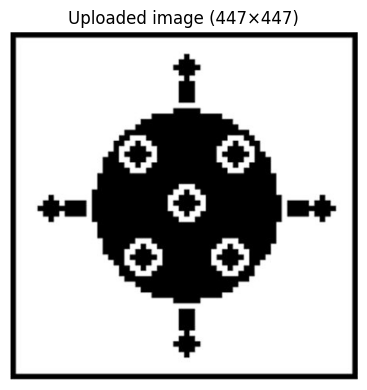

In [4]:
# ── CELL 4 — Upload Watermark Image (stored raw, resized per sweep)
print("🖼️  Upload your B&W watermark image (JPEG/PNG)")
uploaded_img = files.upload()
img_name     = list(uploaded_img.keys())[0]

# Store the original PIL image — we will resize it freshly for each sweep size
IMG_PIL_ORIG = Image.open(img_name).convert('L')
print(f"✅ Loaded image: {img_name}")
print(f"   Original size : {IMG_PIL_ORIG.width} × {IMG_PIL_ORIG.height} px")

plt.figure(figsize=(4, 4))
plt.imshow(IMG_PIL_ORIG, cmap='gray')
plt.title(f'Uploaded image ({IMG_PIL_ORIG.width}×{IMG_PIL_ORIG.height})')
plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
# ── CELL 5 — Core Functions (unchanged from v2) ───────────

def compute_vpk(pk, secret_key):
    return int(hashlib.md5(f"{pk}{secret_key}".encode()).hexdigest(), 16)

def compute_pixel_coord(vpk, img_h, img_w):
    h = int(hashlib.md5(f"{vpk}_h".encode()).hexdigest(), 16) % img_h
    w = int(hashlib.md5(f"{vpk}_w".encode()).hexdigest(), 16) % img_w
    return h, w

def select_msb_bit(vpk, value, num_msb):
    if value <= 0: return 0
    msb_pos = max(value.bit_length() - 1 - (vpk % num_msb), 0)
    return (value >> msb_pos) & 1

def get_lsb(value, bit_pos):
    return (value >> (bit_pos - 1)) & 1

def set_lsb(value, bit_pos, bit_val):
    mask = 1 << (bit_pos - 1)
    return (value & ~mask) | (bit_val << (bit_pos - 1))

def minimize_variation(orig, modified, marked_bit_pos, num_lsb):
    best_val, best_diff = modified, abs(orig - modified)
    for bp in range(1, num_lsb + 1):
        if bp == marked_bit_pos: continue
        for bv in (0, 1):
            c = set_lsb(modified, bp, bv)
            d = abs(orig - c)
            if d < best_diff:
                best_diff, best_val = d, c
    return best_val

def value_tolerable(value, num_lsb):
    return value > 0 and value.bit_length() > (2 * num_lsb)

# ── Pre-compute vpk table once (same for all sweep sizes) ──
# This avoids re-hashing 8399 rows 16 times
print("⚙️  Pre-computing VPK table for all rows...")
VPK_TABLE  = {}   # pk → vpk
RAW_TABLE  = {}   # pk → (attr_name, bit_pos, raw_val, tolerable)

for idx, row in df_original.iterrows():
    pk  = int(row['pk'])
    vpk = compute_vpk(pk, SECRET_KEY)
    VPK_TABLE[pk] = vpk
    if vpk % F != 0:
        RAW_TABLE[pk] = None
        continue
    attr_name = NUMERIC_COLS[vpk % NUM_A]
    bit_pos   = (vpk % NUM_LSB) + 1
    raw_val   = int(round(float(row['Sales']) * SALES_SCALE)) if attr_name == 'Sales' else int(row['Order Quantity'])
    RAW_TABLE[pk] = (attr_name, bit_pos, raw_val, value_tolerable(raw_val, NUM_LSB))

ELIGIBLE_PKS = [pk for pk, v in RAW_TABLE.items() if v is not None and v[3]]
print(f"✅ VPK table ready. Eligible (markable) rows: {len(ELIGIBLE_PKS)} / {len(df_original)}")


def embed_fast(wm_matrix, img_h, img_w):
    """
    Fast embed using pre-computed VPK/RAW tables.
    Returns: (watermarked_df, pixel_hit_matrix, marked_count)
    """
    df_out    = df_original.copy()
    pixel_hit = np.zeros((img_h, img_w), dtype=np.int32)
    marked    = 0

    for pk in ELIGIBLE_PKS:
        vpk                          = VPK_TABLE[pk]
        attr_name, bit_pos, raw_val, _ = RAW_TABLE[pk]
        h, w     = compute_pixel_coord(vpk, img_h, img_w)
        msb_bit  = select_msb_bit(vpk, raw_val, NUM_MSB)
        new_bit  = int(wm_matrix[h, w]) ^ msb_bit
        new_val  = minimize_variation(
            raw_val, set_lsb(raw_val, bit_pos, new_bit), bit_pos, NUM_LSB
        )
        idx = pk - 1   # pk is 1-indexed
        if attr_name == 'Sales':
            df_out.at[idx, 'Sales'] = round(new_val / SALES_SCALE, 2)
        else:
            df_out.at[idx, 'Order Quantity'] = new_val
        pixel_hit[h, w] += 1
        marked += 1

    return df_out, pixel_hit, marked


def extract_fast(df_wm, img_h, img_w):
    """
    Fast extract using pre-computed VPK table.
    Reads from the watermarked dataframe directly.
    """
    ones  = np.zeros((img_h, img_w), dtype=np.int32)
    total = np.zeros((img_h, img_w), dtype=np.int32)

    for pk in ELIGIBLE_PKS:
        vpk                          = VPK_TABLE[pk]
        attr_name, bit_pos, raw_val_orig, _ = RAW_TABLE[pk]
        idx = pk - 1
        # Read from WATERMARKED dataframe (not original)
        if attr_name == 'Sales':
            raw_val = int(round(float(df_wm.at[idx, 'Sales']) * SALES_SCALE))
        else:
            raw_val = int(df_wm.at[idx, 'Order Quantity'])
        if not value_tolerable(raw_val, NUM_LSB): continue
        h, w    = compute_pixel_coord(vpk, img_h, img_w)
        ext_lsb = get_lsb(raw_val, bit_pos)
        msb_bit = select_msb_bit(vpk, raw_val, NUM_MSB)
        ones[h, w]  += ext_lsb ^ msb_bit
        total[h, w] += 1

    ext_wm = np.zeros((img_h, img_w), dtype=np.uint8)
    m = total > 0
    ext_wm[m] = (ones[m] >= (total[m] / 2.0)).astype(np.uint8)
    return ext_wm, total


def recover_image(wm, total_count):
    """8-connected neighbour majority vote for missing pixels."""
    recovered = wm.copy()
    missing   = total_count == 0
    if not missing.any(): return recovered
    img_h, img_w = wm.shape
    for i in range(img_h):
        for j in range(img_w):
            if not missing[i, j]: continue
            nbrs = [
                int(recovered[i+di, j+dj])
                for di in [-1, 0, 1] for dj in [-1, 0, 1]
                if not (di==0 and dj==0)
                and 0 <= i+di < img_h and 0 <= j+dj < img_w
                and not missing[i+di, j+dj]
            ]
            if nbrs:
                recovered[i, j] = 1 if sum(nbrs) >= len(nbrs)/2 else 0
            else:
                si, sj = img_h-1-i, img_w-1-j
                if not missing[si, sj]:
                    recovered[i, j] = recovered[si, sj]
    return recovered


def correction_factor(orig, extracted):
    return 100.0 * np.sum(np.bitwise_xor(orig.astype(np.uint8),
                                          extracted.astype(np.uint8)) == 0) / orig.size

print("✅ All core functions ready.")

⚙️  Pre-computing VPK table for all rows...
✅ VPK table ready. Eligible (markable) rows: 815 / 8399
✅ All core functions ready.


In [6]:
# ── CELL 6 — SIZE SWEEP (12×12 → 255×255) ────────────────
#
# For each size S in SWEEP_SIZES:
#   1. Resize the uploaded JPEG to S×S
#   2. Binarize (threshold 127)
#   3. Embed into the Walmart dataset
#   4. Extract immediately (no attack)
#   5. Run recovery
#   6. Compute CF before and after recovery
#   7. Record all stats
# Then find the optimal size (max CF after recovery)
# ─────────────────────────────────────────────────────────

sweep_records = []

print(f"🔁 Sweeping {len(SWEEP_SIZES)} sizes: {SWEEP_SIZES}")
print(f"   Eligible rows for marking : {len(ELIGIBLE_PKS)}\n")
print(f"{'Size':>8} | {'Pixels':>8} | {'Coverage%':>10} | {'MeanHits':>9} | "
      f"{'MinHits':>8} | {'Missing':>8} | {'CF_before':>10} | {'CF_after':>9} | {'Gain':>6} | {'Time(s)':>8}")
print("-" * 115)

for S in tqdm(SWEEP_SIZES, desc="Size sweep"):
    t0 = time.time()

    # ── Step 1: Resize + binarize ──────────────────────────
    img_resized = IMG_PIL_ORIG.resize((S, S), Image.LANCZOS)
    wm_matrix   = (np.array(img_resized) > 127).astype(np.uint8)
    total_px    = S * S

    # ── Step 2: Embed ──────────────────────────────────────
    df_wm, pixel_hit, marked_count = embed_fast(wm_matrix, S, S)

    # ── Step 3: Extract ────────────────────────────────────
    ext_raw, hit_counts = extract_fast(df_wm, S, S)

    # ── Step 4: Recovery ───────────────────────────────────
    ext_recovered = recover_image(ext_raw, hit_counts)

    # ── Step 5: Metrics ────────────────────────────────────
    pixels_hit   = int((hit_counts > 0).sum())
    pixels_miss  = total_px - pixels_hit
    coverage_pct = 100.0 * pixels_hit / total_px
    mean_hits    = float(pixel_hit.mean())
    min_hits     = int(pixel_hit.min())
    cf_b         = correction_factor(wm_matrix, ext_raw)
    cf_a         = correction_factor(wm_matrix, ext_recovered)
    gain         = cf_a - cf_b
    elapsed      = time.time() - t0

    sweep_records.append({
        'size'        : S,
        'total_pixels': total_px,
        'pixels_hit'  : pixels_hit,
        'pixels_miss' : pixels_miss,
        'coverage_pct': round(coverage_pct, 2),
        'mean_hits'   : round(mean_hits, 2),
        'min_hits'    : min_hits,
        'cf_before'   : round(cf_b, 4),
        'cf_after'    : round(cf_a, 4),
        'cf_gain'     : round(gain, 4),
        'marked_rows' : marked_count,
        'elapsed_s'   : round(elapsed, 1),
    })

    print(f"{S:>5}×{S:<3}| {total_px:>8,} | {coverage_pct:>9.2f}% | "
          f"{mean_hits:>9.2f} | {min_hits:>8} | {pixels_miss:>8} | "
          f"{cf_b:>9.2f}% | {cf_a:>8.2f}% | {gain:>+5.2f}% | {elapsed:>7.1f}s")

sweep_df = pd.DataFrame(sweep_records)
sweep_df.to_csv('size_sweep_results.csv', index=False)

# ── Find optimal ───────────────────────────────────────────
best_row  = sweep_df.loc[sweep_df['cf_after'].idxmax()]
BEST_SIZE = int(best_row['size'])

print("\n" + "═"*60)
print(f"  🏆 OPTIMAL SIZE : {BEST_SIZE}×{BEST_SIZE}")
print(f"     CF after recovery : {best_row['cf_after']:.4f}%")
print(f"     CF before recovery: {best_row['cf_before']:.4f}%")
print(f"     Recovery gain     : {best_row['cf_gain']:+.4f}%")
print(f"     Pixel coverage    : {best_row['coverage_pct']:.2f}%")
print(f"     Mean hits/pixel   : {best_row['mean_hits']:.2f}")
print(f"     Missing pixels    : {int(best_row['pixels_miss'])}")
print("═"*60)
print("\n✅ size_sweep_results.csv saved")

🔁 Sweeping 16 sizes: [12, 25, 32, 40, 50, 64, 75, 90, 100, 112, 128, 150, 175, 200, 225, 255]
   Eligible rows for marking : 815

    Size |   Pixels |  Coverage% |  MeanHits |  MinHits |  Missing |  CF_before |  CF_after |   Gain |  Time(s)
-------------------------------------------------------------------------------------------------------------------


Size sweep:   0%|          | 0/16 [00:00<?, ?it/s]

   12×12 |      144 |     99.31% |      5.66 |        0 |        1 |     99.31% |   100.00% | +0.69% |     0.0s
   25×25 |      625 |     73.28% |      1.30 |        0 |      167 |     78.88% |    97.44% | +18.56% |     0.0s
   32×32 |    1,024 |     55.08% |      0.80 |        0 |      460 |     64.45% |    95.61% | +31.15% |     0.0s
   40×40 |    1,600 |     39.69% |      0.51 |        0 |      965 |     59.56% |    88.94% | +29.38% |     0.0s
   50×50 |    2,500 |     28.16% |      0.33 |        0 |     1796 |     50.16% |    88.40% | +38.24% |     0.0s
   64×64 |    4,096 |     18.14% |      0.20 |        0 |     3353 |     42.26% |    81.23% | +38.96% |     0.0s
   75×75 |    5,625 |     13.64% |      0.14 |        0 |     4858 |     37.53% |    76.75% | +39.22% |     0.1s
   90×90 |    8,100 |      9.54% |      0.10 |        0 |     7327 |     36.11% |    69.41% | +33.30% |     0.1s
  100×100|   10,000 |      7.83% |      0.08 |        0 |     9217 |     36.22% |    65.97% | +29

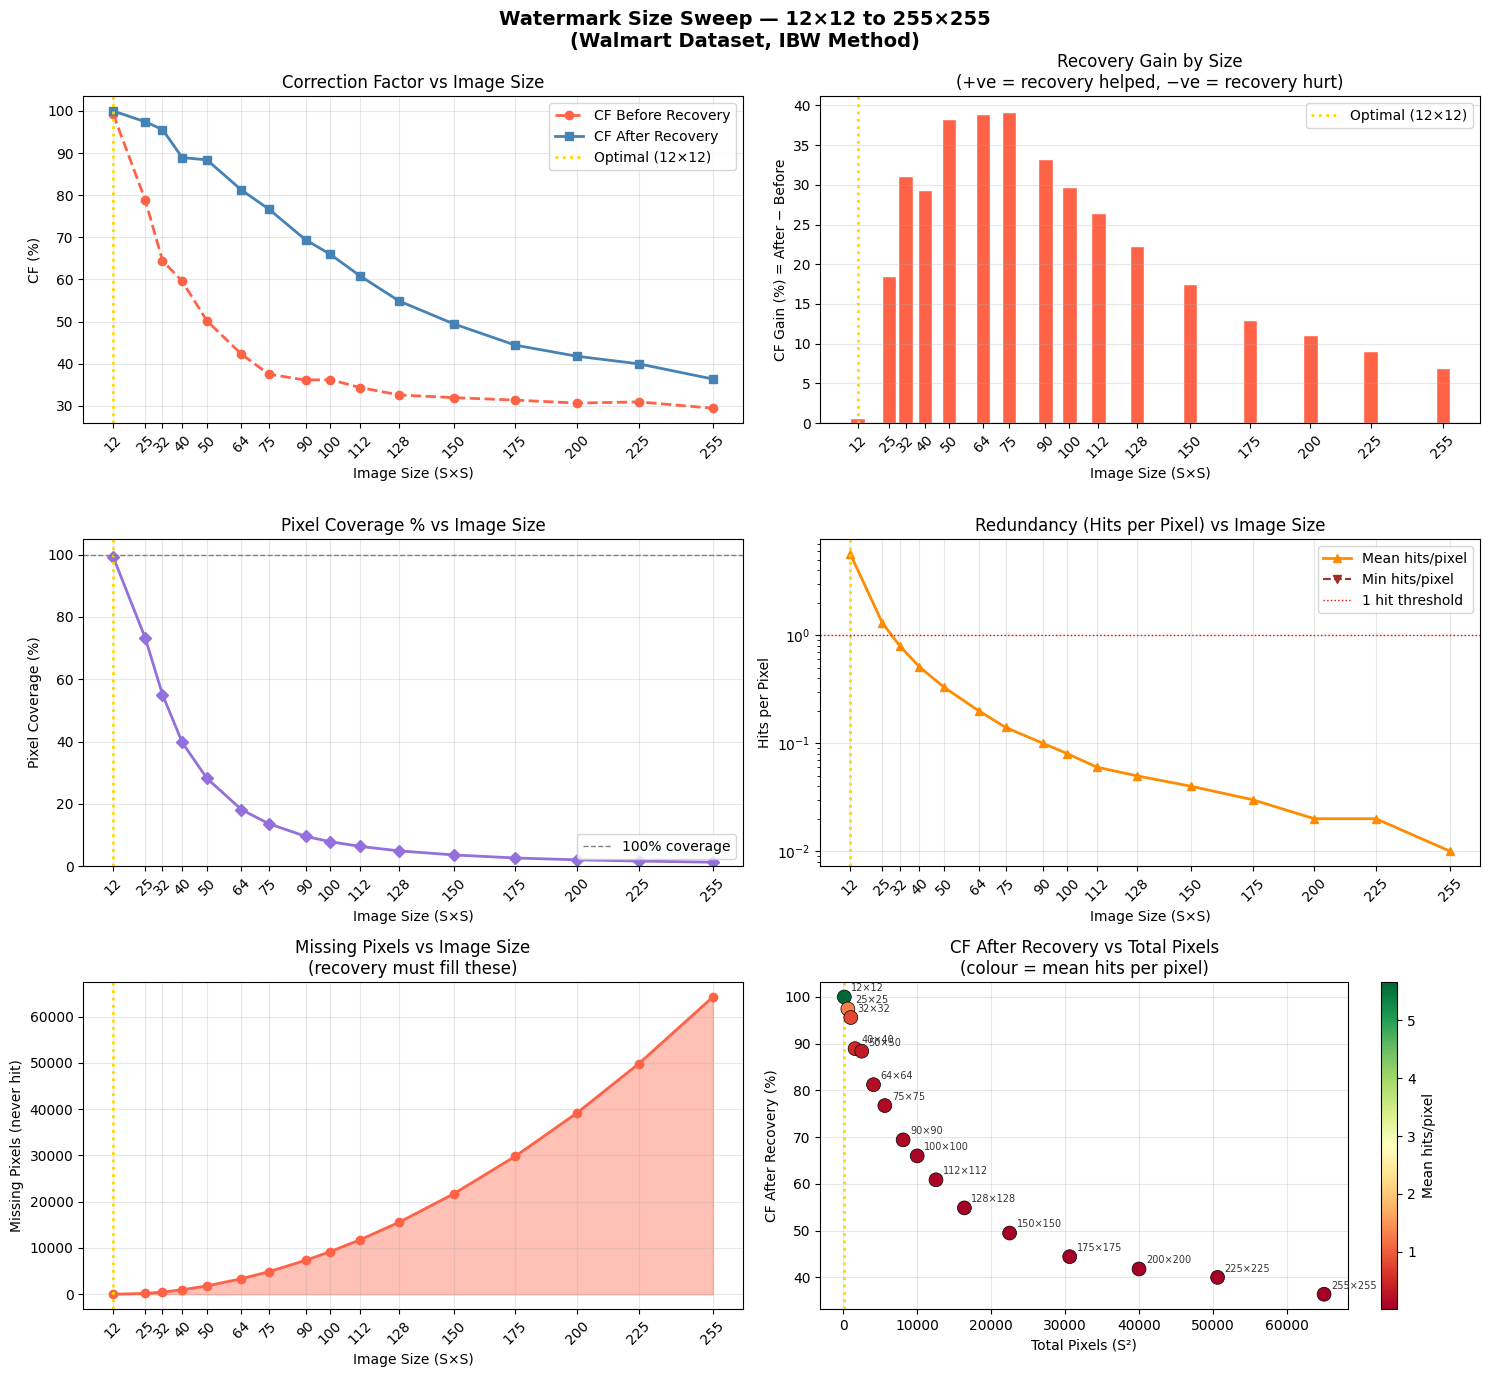

✅ sweep_analysis.png saved


In [7]:
# ── CELL 7 — Sweep Visualisations ────────────────────────

sizes  = sweep_df['size'].values
pixels = sweep_df['total_pixels'].values

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
fig.suptitle('Watermark Size Sweep — 12×12 to 255×255\n(Walmart Dataset, IBW Method)',
             fontsize=14, fontweight='bold')

# ── Plot 1: CF before and after recovery vs size ──────────
ax = axes[0, 0]
ax.plot(sizes, sweep_df['cf_before'], 'o--', color='tomato',    label='CF Before Recovery', lw=2)
ax.plot(sizes, sweep_df['cf_after'],  's-',  color='steelblue', label='CF After Recovery',  lw=2)
ax.axvline(BEST_SIZE, color='gold', linestyle=':', lw=2, label=f'Optimal ({BEST_SIZE}×{BEST_SIZE})')
ax.set_xlabel('Image Size (S×S)'); ax.set_ylabel('CF (%)')
ax.set_title('Correction Factor vs Image Size')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xticks(sizes); ax.tick_params(axis='x', rotation=45)

# ── Plot 2: CF gain (after − before) vs size ─────────────
ax = axes[0, 1]
colors = ['tomato' if g > 0 else 'steelblue' for g in sweep_df['cf_gain']]
bars   = ax.bar(sizes, sweep_df['cf_gain'], color=colors, edgecolor='white', width=6)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(BEST_SIZE, color='gold', linestyle=':', lw=2, label=f'Optimal ({BEST_SIZE}×{BEST_SIZE})')
ax.set_xlabel('Image Size (S×S)'); ax.set_ylabel('CF Gain (%) = After − Before')
ax.set_title('Recovery Gain by Size\n(+ve = recovery helped, −ve = recovery hurt)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
ax.set_xticks(sizes); ax.tick_params(axis='x', rotation=45)

# ── Plot 3: Pixel coverage % vs size ─────────────────────
ax = axes[1, 0]
ax.plot(sizes, sweep_df['coverage_pct'], 'D-', color='mediumpurple', lw=2)
ax.axvline(BEST_SIZE, color='gold', linestyle=':', lw=2)
ax.axhline(100, color='gray', linestyle='--', lw=1, label='100% coverage')
ax.set_xlabel('Image Size (S×S)'); ax.set_ylabel('Pixel Coverage (%)')
ax.set_title('Pixel Coverage % vs Image Size')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xticks(sizes); ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 105)

# ── Plot 4: Mean hits per pixel vs size ──────────────────
ax = axes[1, 1]
ax.plot(sizes, sweep_df['mean_hits'], '^-', color='darkorange', lw=2, label='Mean hits/pixel')
ax.plot(sizes, sweep_df['min_hits'],  'v--', color='brown',     lw=1.5, label='Min hits/pixel')
ax.axvline(BEST_SIZE, color='gold', linestyle=':', lw=2)
ax.axhline(1, color='red', linestyle=':', lw=1, label='1 hit threshold')
ax.set_xlabel('Image Size (S×S)'); ax.set_ylabel('Hits per Pixel')
ax.set_title('Redundancy (Hits per Pixel) vs Image Size')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xticks(sizes); ax.tick_params(axis='x', rotation=45)
ax.set_yscale('log')

# ── Plot 5: Missing pixels vs size ───────────────────────
ax = axes[2, 0]
ax.fill_between(sizes, sweep_df['pixels_miss'], alpha=0.4, color='tomato')
ax.plot(sizes, sweep_df['pixels_miss'], 'o-', color='tomato', lw=2)
ax.axvline(BEST_SIZE, color='gold', linestyle=':', lw=2)
ax.set_xlabel('Image Size (S×S)'); ax.set_ylabel('Missing Pixels (never hit)')
ax.set_title('Missing Pixels vs Image Size\n(recovery must fill these)')
ax.grid(True, alpha=0.3)
ax.set_xticks(sizes); ax.tick_params(axis='x', rotation=45)

# ── Plot 6: CF after recovery vs total pixels (scatter) ──
ax = axes[2, 1]
sc = ax.scatter(pixels, sweep_df['cf_after'],
                c=sweep_df['mean_hits'], cmap='RdYlGn',
                s=100, edgecolors='black', linewidths=0.5, zorder=3)
plt.colorbar(sc, ax=ax, label='Mean hits/pixel')
for _, r in sweep_df.iterrows():
    ax.annotate(f"{int(r['size'])}×{int(r['size'])}",
                (r['total_pixels'], r['cf_after']),
                textcoords='offset points', xytext=(5, 4), fontsize=7, color='#333')
ax.axvline(BEST_SIZE**2, color='gold', linestyle=':', lw=2)
ax.set_xlabel('Total Pixels (S²)'); ax.set_ylabel('CF After Recovery (%)')
ax.set_title('CF After Recovery vs Total Pixels\n(colour = mean hits per pixel)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sweep_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ sweep_analysis.png saved")

🖼️  Generating visual grid of all extracted watermarks...


Rendering:   0%|          | 0/16 [00:00<?, ?it/s]

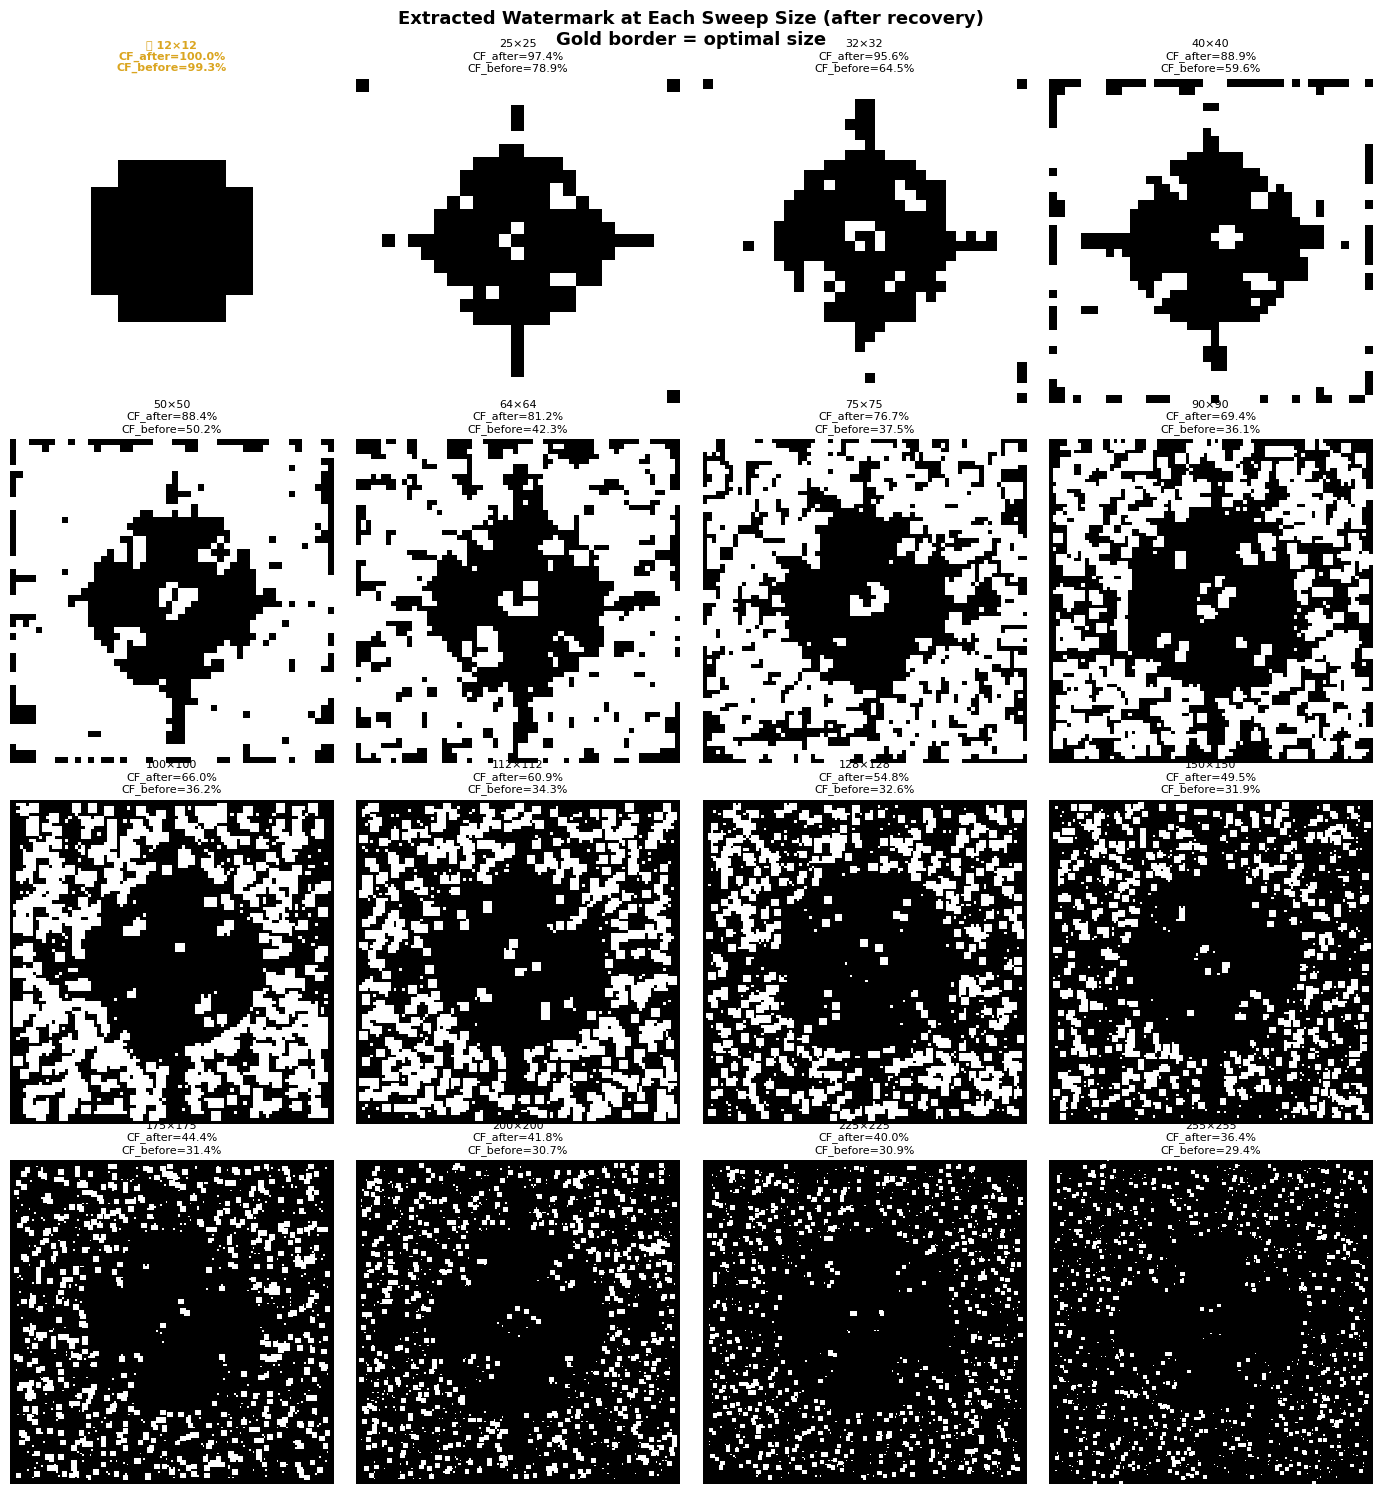

✅ sweep_visual_grid.png saved


In [8]:
# ── CELL 8 — Visual Grid: Extracted Watermarks at Every Size
# Shows what the recovered image actually LOOKS LIKE at each size
# ─────────────────────────────────────────────────────────

n    = len(SWEEP_SIZES)
ncol = 4
nrow = math.ceil(n / ncol)

fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*3.5, nrow*3.8))
axes_flat = axes.flatten()

print("🖼️  Generating visual grid of all extracted watermarks...")

for i, S in enumerate(tqdm(SWEEP_SIZES, desc="Rendering")):
    img_resized = IMG_PIL_ORIG.resize((S, S), Image.LANCZOS)
    wm_matrix   = (np.array(img_resized) > 127).astype(np.uint8)

    df_wm, pixel_hit_s, _  = embed_fast(wm_matrix, S, S)
    ext_raw, hit_counts_s  = extract_fast(df_wm, S, S)
    ext_recovered          = recover_image(ext_raw, hit_counts_s)

    cf_b = correction_factor(wm_matrix, ext_raw)
    cf_a = correction_factor(wm_matrix, ext_recovered)

    ax = axes_flat[i]
    ax.imshow(ext_recovered, cmap='gray', vmin=0, vmax=1, interpolation='nearest')

    is_best  = (S == BEST_SIZE)
    border_c = 'gold' if is_best else 'none'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_c)
        spine.set_linewidth(4 if is_best else 1)

    title_str  = f"{'🏆 ' if is_best else ''}{S}×{S}"
    subtitle   = f"CF_after={cf_a:.1f}%\nCF_before={cf_b:.1f}%"
    ax.set_title(f"{title_str}\n{subtitle}", fontsize=8,
                 color='goldenrod' if is_best else 'black', fontweight='bold' if is_best else 'normal')
    ax.axis('off')

# Hide empty subplots
for j in range(i+1, len(axes_flat)):
    axes_flat[j].axis('off')

fig.suptitle('Extracted Watermark at Each Sweep Size (after recovery)\nGold border = optimal size',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sweep_visual_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ sweep_visual_grid.png saved")

In [9]:
# ── CELL 9 — Summary Table ────────────────────────────────

display_df = sweep_df[[
    'size','total_pixels','coverage_pct','mean_hits','min_hits',
    'pixels_miss','cf_before','cf_after','cf_gain'
]].copy()
display_df.columns = [
    'Size','Total Pixels','Coverage %','Mean Hits','Min Hits',
    'Missing Px','CF Before %','CF After %','Gain %'
]

def highlight_best(row):
    if row['Size'] == BEST_SIZE:
        return ['background-color: #fff3cd; font-weight: bold'] * len(row)
    elif row['CF After %'] >= 99:
        return ['background-color: #d4edda'] * len(row)
    elif row['CF After %'] < 80:
        return ['background-color: #f8d7da'] * len(row)
    return [''] * len(row)

styled = display_df.style.apply(highlight_best, axis=1).format({
    'Coverage %' : '{:.2f}%',
    'Mean Hits'  : '{:.2f}',
    'CF Before %': '{:.4f}%',
    'CF After %' : '{:.4f}%',
    'Gain %'     : '{:+.4f}%',
})
display(styled)

# Interpretation guide
print("\n🟨 Gold row     = optimal size (max CF after recovery)")
print("🟩 Green rows   = CF after ≥ 99%  (excellent)")
print("🟥 Red rows     = CF after < 80%  (poor — too large for dataset)")
print()

# Key insight printout
safe_sizes   = sweep_df[sweep_df['coverage_pct'] == 100.0]
unsafe_sizes = sweep_df[sweep_df['coverage_pct'] < 100.0]
print(f"✅ Sizes with 100% pixel coverage : {safe_sizes['size'].tolist()}")
print(f"⚠️  Sizes with <100% coverage     : {unsafe_sizes['size'].tolist()}")
print(f"\n   At {BEST_SIZE}×{BEST_SIZE} (optimal):")
print(f"   → Every pixel gets ≥ {int(best_row['min_hits'])} vote(s)")
print(f"   → Mean votes per pixel: {best_row['mean_hits']:.1f}")
print(f"   → Missing pixels (need recovery): {int(best_row['pixels_miss'])}")

,Size,Total Pixels,Coverage %,Mean Hits,Min Hits,Missing Px,CF Before %,CF After %,Gain %
0,12,144,99.31%,5.66,0,1,99.3056%,100.0000%,+0.6944%
1,25,625,73.28%,1.30,0,167,78.8800%,97.4400%,+18.5600%
2,32,1024,55.08%,0.80,0,460,64.4531%,95.6055%,+31.1523%
3,40,1600,39.69%,0.51,0,965,59.5625%,88.9375%,+29.3750%
4,50,2500,28.16%,0.33,0,1796,50.1600%,88.4000%,+38.2400%
5,64,4096,18.14%,0.20,0,3353,42.2607%,81.2256%,+38.9648%
6,75,5625,13.64%,0.14,0,4858,37.5289%,76.7467%,+39.2178%
7,90,8100,9.54%,0.10,0,7327,36.1111%,69.4074%,+33.2963%
8,100,10000,7.83%,0.08,0,9217,36.2200%,65.9700%,+29.7500%
9,112,12544,6.32%,0.06,0,11751,34.3431%,60.8578%,+26.5147%



🟨 Gold row     = optimal size (max CF after recovery)
🟩 Green rows   = CF after ≥ 99%  (excellent)
🟥 Red rows     = CF after < 80%  (poor — too large for dataset)

✅ Sizes with 100% pixel coverage : []
⚠️  Sizes with <100% coverage     : [12, 25, 32, 40, 50, 64, 75, 90, 100, 112, 128, 150, 175, 200, 225, 255]

   At 12×12 (optimal):
   → Every pixel gets ≥ 0 vote(s)
   → Mean votes per pixel: 5.7
   → Missing pixels (need recovery): 1


🏆 Running full pipeline at optimal size: 12×12

  Marked rows         : 815
  Pixel coverage      : 143/144 (99.3%)
  Mean hits/pixel     : 5.66
  CF before recovery  : 99.3056%
  CF after  recovery  : 100.0000%

  Attack % |    CF Before |    CF After
----------------------------------------
         0% |     99.3056% |   100.0000%
        10% |     99.3056% |   100.0000%
        20% |     99.3056% |   100.0000%
        30% |     97.9167% |    98.6111%
        40% |     98.6111% |    99.3056%
        50% |     98.6111% |    99.3056%
        60% |     97.9167% |    98.6111%
        70% |     98.6111% |    99.3056%
        80% |     97.9167% |    98.6111%
        90% |     96.5278% |    97.2222%


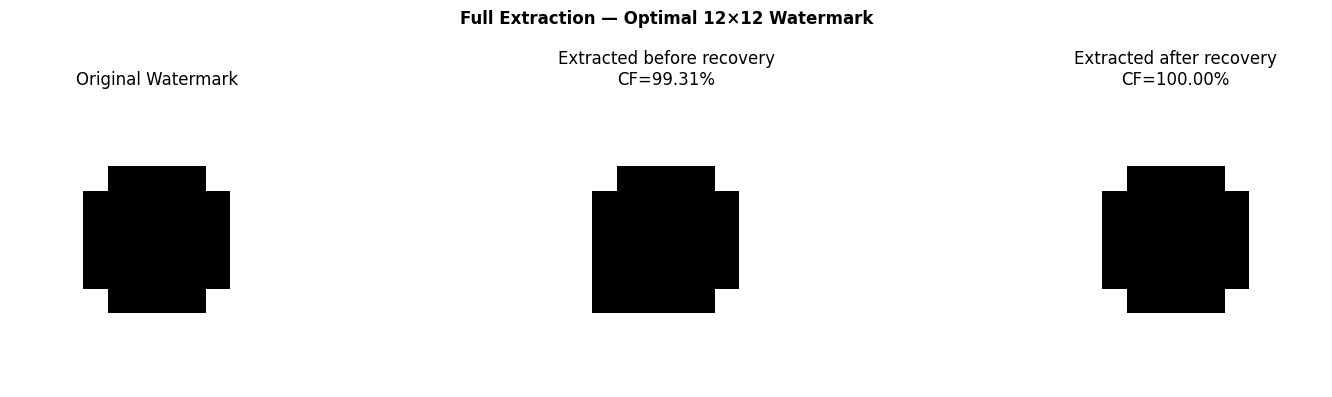

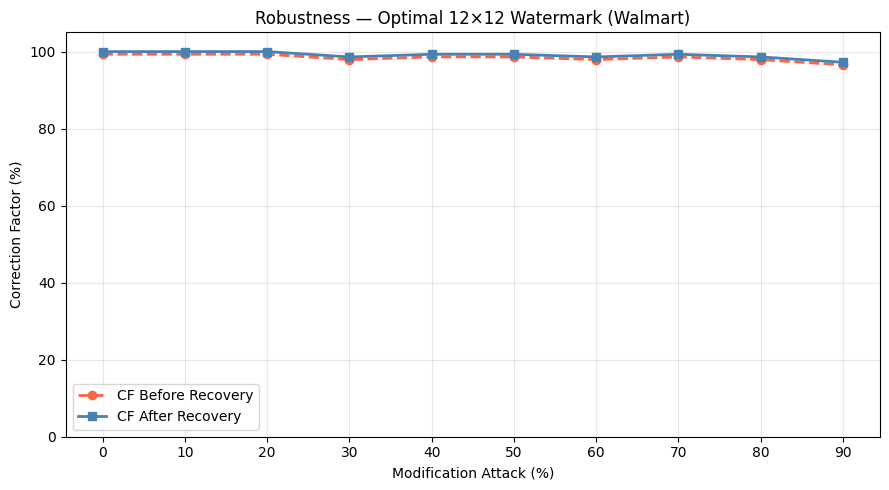

✅ All optimal-size outputs saved


In [10]:
# ── CELL 10 — Full Pipeline at Optimal Size ───────────────
# Re-run embed + extract + attack simulation at BEST_SIZE

print(f"🏆 Running full pipeline at optimal size: {BEST_SIZE}×{BEST_SIZE}\n")

# Build final watermark matrix at best size
img_best   = IMG_PIL_ORIG.resize((BEST_SIZE, BEST_SIZE), Image.LANCZOS)
WM_BEST    = (np.array(img_best) > 127).astype(np.uint8)
IMG_H, IMG_W = BEST_SIZE, BEST_SIZE
TOTAL_PX   = BEST_SIZE * BEST_SIZE

# Embed
df_wm_best, pixel_hit_best, marked_best = embed_fast(WM_BEST, IMG_H, IMG_W)
df_wm_best.to_csv('watermarked_walmart.csv', index=False)

# Extract
ext_raw_best, hits_best = extract_fast(df_wm_best, IMG_H, IMG_W)
ext_rec_best            = recover_image(ext_raw_best, hits_best)
cf_b_best               = correction_factor(WM_BEST, ext_raw_best)
cf_a_best               = correction_factor(WM_BEST, ext_rec_best)

Image.fromarray((ext_rec_best * 255).astype(np.uint8)).save('extracted_watermark_optimal.png')

print(f"  Marked rows         : {marked_best}")
print(f"  Pixel coverage      : {(hits_best>0).sum()}/{TOTAL_PX} ({100*(hits_best>0).sum()/TOTAL_PX:.1f}%)")
print(f"  Mean hits/pixel     : {pixel_hit_best.mean():.2f}")
print(f"  CF before recovery  : {cf_b_best:.4f}%")
print(f"  CF after  recovery  : {cf_a_best:.4f}%")

# Attack simulation at optimal size
def simulate_attack(df_wm, attack_pct, seed=42):
    rng = np.random.default_rng(seed)
    df_att   = df_wm.copy()
    n_attack = int(len(df_att) * attack_pct / 100.0)
    att_rows = rng.choice(len(df_att), size=n_attack, replace=False)
    for ri in att_rows:
        col = rng.choice(NUMERIC_COLS)
        bp  = int(rng.integers(1, NUM_LSB + 1))
        if col == 'Sales':
            v = int(round(float(df_att.iloc[ri]['Sales']) * SALES_SCALE))
            if v > 0:
                df_att.iloc[ri, df_att.columns.get_loc('Sales')] = round((v ^ (1 << (bp-1))) / SALES_SCALE, 2)
        else:
            v = int(df_att.iloc[ri]['Order Quantity'])
            if v > 0:
                df_att.iloc[ri, df_att.columns.get_loc('Order Quantity')] = v ^ (1 << (bp-1))
    return df_att

attack_levels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
cf_results    = []

print(f"\n{'Attack %':>10} | {'CF Before':>12} | {'CF After':>11}")
print("-" * 40)
for pct in attack_levels:
    df_att   = df_wm_best.copy() if pct == 0 else simulate_attack(df_wm_best, pct)
    e_r, h_c = extract_fast(df_att, IMG_H, IMG_W)
    e_rec    = recover_image(e_r, h_c)
    cb, ca   = correction_factor(WM_BEST, e_r), correction_factor(WM_BEST, e_rec)
    cf_results.append({'Attack %': pct, 'CF Before': cb, 'CF After': ca})
    print(f"{pct:>10}% | {cb:>11.4f}% | {ca:>10.4f}%")

cf_df = pd.DataFrame(cf_results)
cf_df.to_csv('attack_cf_results_optimal.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, mat, title in zip(axes,
    [WM_BEST, ext_raw_best, ext_rec_best],
    ['Original Watermark', f'Extracted before recovery\nCF={cf_b_best:.2f}%',
     f'Extracted after recovery\nCF={cf_a_best:.2f}%']):
    ax.imshow(mat, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title); ax.axis('off')
plt.suptitle(f'Full Extraction — Optimal {BEST_SIZE}×{BEST_SIZE} Watermark', fontweight='bold')
plt.tight_layout()
plt.savefig('extraction_optimal.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(cf_df['Attack %'], cf_df['CF Before'], 'o--', color='tomato',    label='CF Before Recovery', lw=2)
plt.plot(cf_df['Attack %'], cf_df['CF After'],  's-',  color='steelblue', label='CF After Recovery',  lw=2)
plt.xlabel('Modification Attack (%)'); plt.ylabel('Correction Factor (%)')
plt.title(f'Robustness — Optimal {BEST_SIZE}×{BEST_SIZE} Watermark (Walmart)')
plt.legend(); plt.grid(True, alpha=0.3); plt.xticks(attack_levels); plt.ylim(0, 105)
plt.tight_layout()
plt.savefig('attack_robustness_optimal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All optimal-size outputs saved")

In [11]:
# ── CELL 11 — Full Sweep Report ───────────────────────────

lines = [
    "="*70,
    "  IBW WATERMARKING — SIZE SWEEP REPORT",
    "  Sardroudi & Ibrahim (2010) | Walmart Dataset",
    "="*70,
    "",
    f"  Dataset         : Walmart ({len(df)} rows)",
    f"  SECRET_KEY      : {SECRET_KEY}",
    f"  F / NUM_LSB / NUM_MSB : {F} / {NUM_LSB} / {NUM_MSB}",
    f"  Eligible rows   : {len(ELIGIBLE_PKS)}",
    f"  Sizes tested    : {SWEEP_SIZES}",
    "",
    f"{'Size':>8} | {'Pixels':>8} | {'Cover%':>7} | {'MeanHit':>8} | "
    f"{'Miss':>6} | {'CF_before':>10} | {'CF_after':>9} | {'Gain':>7}",
    "-"*80,
] + [
    f"{'→'+str(int(r['size']))+'×'+str(int(r['size'])) if int(r['size'])==BEST_SIZE else str(int(r['size']))+'×'+str(int(r['size'])):>8} | "
    f"{int(r['total_pixels']):>8,} | {r['coverage_pct']:>6.2f}% | "
    f"{r['mean_hits']:>8.2f} | {int(r['pixels_miss']):>6} | "
    f"{r['cf_before']:>9.4f}% | {r['cf_after']:>8.4f}% | {r['cf_gain']:>+6.4f}%"
    for _, r in sweep_df.iterrows()
] + [
    "",
    "="*70,
    f"  🏆 OPTIMAL SIZE : {BEST_SIZE}×{BEST_SIZE}",
    f"     CF after recovery  : {best_row['cf_after']:.4f}%",
    f"     CF before recovery : {best_row['cf_before']:.4f}%",
    f"     Recovery gain      : {best_row['cf_gain']:+.4f}%",
    f"     Pixel coverage     : {best_row['coverage_pct']:.2f}%",
    f"     Mean hits/pixel    : {best_row['mean_hits']:.2f}",
    f"     Missing pixels     : {int(best_row['pixels_miss'])}",
    "",
    "── ATTACK ROBUSTNESS AT OPTIMAL SIZE ────────────────────────────",
] + [
    f"  {int(r['Attack %']):>3}% attack  →  CF before: {r['CF Before']:>8.4f}%   CF after: {r['CF After']:>8.4f}%"
    for _, r in cf_df.iterrows()
] + ["", "="*70]

report = "\n".join(lines)
print(report)
with open('sweep_cf_report.txt', 'w') as f: f.write(report)
print("\n✅ sweep_cf_report.txt saved")

  IBW WATERMARKING — SIZE SWEEP REPORT
  Sardroudi & Ibrahim (2010) | Walmart Dataset

  Dataset         : Walmart (8399 rows)
  SECRET_KEY      : walmart_ibw_2024
  F / NUM_LSB / NUM_MSB : 5 / 4 / 2
  Eligible rows   : 815
  Sizes tested    : [12, 25, 32, 40, 50, 64, 75, 90, 100, 112, 128, 150, 175, 200, 225, 255]

    Size |   Pixels |  Cover% |  MeanHit |   Miss |  CF_before |  CF_after |    Gain
--------------------------------------------------------------------------------
  →12×12 |      144 |  99.31% |     5.66 |      1 |   99.3056% | 100.0000% | +0.6944%
   25×25 |      625 |  73.28% |     1.30 |    167 |   78.8800% |  97.4400% | +18.5600%
   32×32 |    1,024 |  55.08% |     0.80 |    460 |   64.4531% |  95.6055% | +31.1523%
   40×40 |    1,600 |  39.69% |     0.51 |    965 |   59.5625% |  88.9375% | +29.3750%
   50×50 |    2,500 |  28.16% |     0.33 |   1796 |   50.1600% |  88.4000% | +38.2400%
   64×64 |    4,096 |  18.14% |     0.20 |   3353 |   42.2607% |  81.2256% | +38.9

In [12]:
# ── CELL 12 — Download All Outputs ───────────────────────
for fname in [
    'original_walmart.csv',
    'watermarked_walmart.csv',
    'size_sweep_results.csv',
    'attack_cf_results_optimal.csv',
    'sweep_cf_report.txt',
    'sweep_analysis.png',
    'sweep_visual_grid.png',
    'extraction_optimal.png',
    'extracted_watermark_optimal.png',
    'attack_robustness_optimal.png',
]:
    try:
        files.download(fname)
        print(f"✅ {fname}")
    except Exception as e:
        print(f"⚠️  {fname} — {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ original_walmart.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ extracted_watermark_optimal.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ attack_robustness_optimal.png
